In [1]:
# 1. Enhanced Setup and Dependencies
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn vaderSentiment optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import pickle
import json
warnings.filterwarnings('ignore')

# Import our enhanced modules
from enhanced_features import AdvancedFeatureEngineer
from enhanced_models import EnhancedMLPipeline
from model_monitoring import ModelMonitor
from enhanced_features import load_and_merge_all_platforms, AdvancedFeatureEngineer

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Enhanced libraries and modules loaded successfully!")
print("🚀 Ready for advanced game investment analysis!")


✅ Enhanced libraries and modules loaded successfully!
🚀 Ready for advanced game investment analysis!


In [2]:
# 2. Data Loading with Enhanced Preprocessing
print("📊 Loading and merging all platform data (Twitch, YouTube, Reddit, Steam)...")

# Load and merge all platform data using the enhanced function
master_df = load_and_merge_all_platforms(
    twitch_csv='twitch_game_streams.csv',
    youtube_csv='youtube_game_videos.csv',
    reddit_csv='reddit_game_posts.csv',
    steam_csv='steam_significant_games.csv',
    fuzzy_match=True  # Set to False if you want exact title matching
)

print(f"✅ All platform data loaded and merged successfully!")
print(f"📊 Master dataset: {len(master_df)} games with {len(master_df.columns)} features")

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(master_df, test_size=0.2, random_state=42)
print(f"Training set: {len(train_df)}, Test set: {len(test_df)}")

# Display Steam columns that were loaded
steam_columns = [col for col in master_df.columns if 'steam_' in col.lower()]
print(f"\n🎮 Steam features loaded ({len(steam_columns)} features):")
for col in steam_columns[:10]:  # Show first 10 Steam features
    print(f"   • {col}")
if len(steam_columns) > 10:
    print(f"   ... and {len(steam_columns) - 10} more Steam features")

# Show sample of platform presence
steam_numeric_cols = [
    col for col in master_df.columns
    if 'steam_' in col.lower() and pd.api.types.is_numeric_dtype(master_df[col])
]
platform_counts_fixed = {}
for platform in ['twitch', 'youtube', 'reddit', 'steam']:
    platform_cols = [col for col in master_df.columns if platform in col.lower()]
    if platform_cols:
        # Check if there are any non-null values
        has_data = master_df[platform_cols].notna().any(axis=1).sum()
        platform_counts_fixed[platform.capitalize()] = has_data
    else:
        platform_counts_fixed[platform.capitalize()] = 0

print("Fixed platform coverage:")
for platform, count in platform_counts_fixed.items():
    percentage = (count / len(master_df)) * 100
    print(f"   {platform}: {count:,} games ({percentage:.1f}%)")

feature_engineer = AdvancedFeatureEngineer()

# Training set
numeric_columns = train_df.select_dtypes(include=[np.number]).columns
train_df[numeric_columns] = train_df[numeric_columns].fillna(0)
train_df_enhanced = feature_engineer.create_temporal_features(train_df)
train_df_enhanced = feature_engineer.create_cross_platform_features(train_df_enhanced)
train_df_enhanced = feature_engineer.create_engagement_quality_features(train_df_enhanced)
train_df_enhanced = feature_engineer.create_network_features(train_df_enhanced)
train_df_enhanced = feature_engineer.create_viral_potential_features(train_df_enhanced)
train_df_enhanced = feature_engineer.create_competitive_features(train_df_enhanced)
target_components = {
    'twitch_component': train_df_enhanced['twitch_total_viewers'] * 0.15,
    'youtube_component': train_df_enhanced['youtube_total_views'] * 0.0001,
    'reddit_component': train_df_enhanced['reddit_total_score'] * 1.2,
    'engagement_component': train_df_enhanced['cross_platform_engagement_rate'] * 500,
    'viral_component': train_df_enhanced['viral_potential_score'] * 200
}
train_df_enhanced['enhanced_engagement_score'] = sum(target_components.values())
train_df_enhanced['platform_presence'] = (
    (train_df_enhanced['twitch_total_viewers'] > 0).astype(int) +
    (train_df_enhanced['youtube_total_views'] > 0).astype(int) +
    (train_df_enhanced['reddit_total_score'] > 0).astype(int)
)
train_df_enhanced['investment_potential'] = pd.cut(
    train_df_enhanced['enhanced_engagement_score'], 
    bins=[0, 100, 500, 2000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)
print(f"✅ Training set feature engineering completed: {len(train_df_enhanced)} games, {len(train_df_enhanced.columns)} features")

# Test set
numeric_columns_test = test_df.select_dtypes(include=[np.number]).columns
test_df[numeric_columns_test] = test_df[numeric_columns_test].fillna(0)
test_df_enhanced = feature_engineer.create_temporal_features(test_df)
test_df_enhanced = feature_engineer.create_cross_platform_features(test_df_enhanced)
test_df_enhanced = feature_engineer.create_engagement_quality_features(test_df_enhanced)
test_df_enhanced = feature_engineer.create_network_features(test_df_enhanced)
test_df_enhanced = feature_engineer.create_viral_potential_features(test_df_enhanced)
test_df_enhanced = feature_engineer.create_competitive_features(test_df_enhanced)
target_components_test = {
    'twitch_component': test_df_enhanced['twitch_total_viewers'] * 0.15,
    'youtube_component': test_df_enhanced['youtube_total_views'] * 0.0001,
    'reddit_component': test_df_enhanced['reddit_total_score'] * 1.2,
    'engagement_component': test_df_enhanced['cross_platform_engagement_rate'] * 500,
    'viral_component': test_df_enhanced['viral_potential_score'] * 200
}
test_df_enhanced['enhanced_engagement_score'] = sum(target_components_test.values())
test_df_enhanced['platform_presence'] = (
    (test_df_enhanced['twitch_total_viewers'] > 0).astype(int) +
    (test_df_enhanced['youtube_total_views'] > 0).astype(int) +
    (test_df_enhanced['reddit_total_score'] > 0).astype(int)
)
test_df_enhanced['investment_potential'] = pd.cut(
    test_df_enhanced['enhanced_engagement_score'], 
    bins=[0, 100, 500, 2000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)
print(f"✅ Test set feature engineering completed: {len(test_df_enhanced)} games, {len(test_df_enhanced.columns)} features")
# ========== Feature engineering completed ==========


📊 Loading and merging all platform data (Twitch, YouTube, Reddit, Steam)...
✅ twitch_game_streams.csv loaded with utf-8 encoding
✅ youtube_game_videos.csv loaded with latin1 encoding
✅ reddit_game_posts.csv loaded with utf-8 encoding
✅ steam_significant_games.csv loaded with latin1 encoding
✅ All platform data loaded and merged successfully!
📊 Master dataset: 1406 games with 64 features
Training set: 1124, Test set: 282

🎮 Steam features loaded (14 features):
   • steam_appid
   • steam_name
   • steam_metacritic
   • steam_developers
   • steam_publishers
   • steam_review_count
   • steam_positive_rate
   • steam_positive_count
   • steam_sentiment_score
   • steam_current_players
   ... and 4 more Steam features
Fixed platform coverage:
   Twitch: 34 games (2.4%)
   Youtube: 1,290 games (91.7%)
   Reddit: 1,320 games (93.9%)
   Steam: 1,307 games (93.0%)
✅ Training set feature engineering completed: 1124 games, 95 features
✅ Test set feature engineering completed: 282 games, 95 feat

In [3]:
# 检查 Steam 数据加载
print("=== 检查 Steam 数据加载 ===")
steam_data = pd.read_csv('steam_significant_games.csv')
print(f"Steam 原始数据: {len(steam_data)} 行, {len(steam_data.columns)} 列")
print(f"Steam 数据前5行:")
print(steam_data.head())
print(f"Steam 数据列名: {list(steam_data.columns)}")

=== 检查 Steam 数据加载 ===


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x80 in position 16410: invalid start byte

In [ ]:
# 检查合并后的数据
print("=== 检查合并后的数据 ===")
print(f"master_df 形状: {master_df.shape}")
print(f"master_df 列名: {list(master_df.columns)}")

# 检查 Steam 相关列
steam_cols = [col for col in master_df.columns if 'steam_' in col.lower()]
print(f"Steam 相关列: {steam_cols}")
print(f"Steam 列数量: {len(steam_cols)}")

# 检查每个平台的数据
print(f"\n各平台数据统计:")
for platform in ['twitch', 'youtube', 'reddit', 'steam']:
    platform_cols = [col for col in master_df.columns if platform in col.lower()]
    if platform_cols:
        non_null_count = master_df[platform_cols[0]].notna().sum()
        print(f"{platform.capitalize()}: {non_null_count} 游戏有数据")
    else:
        print(f"{platform.capitalize()}: 没有找到相关列")

=== 检查合并后的数据 ===
master_df 形状: (1405, 68)
master_df 列名: ['game_title', 'twitch_total_viewers', 'twitch_avg_viewers', 'twitch_max_viewers', 'twitch_viewer_std', 'twitch_stream_count', 'twitch_unique_streamers', 'twitch_viewer_cv', 'youtube_total_views', 'youtube_avg_views', 'youtube_max_views', 'youtube_view_std', 'youtube_video_count', 'youtube_total_likes', 'youtube_avg_likes', 'youtube_max_likes', 'youtube_total_comments', 'youtube_avg_comments', 'youtube_max_comments', 'youtube_avg_sentiment', 'youtube_sentiment_std', 'youtube_pos_ratio', 'youtube_pos_ratio_std', 'youtube_total_subscribers', 'youtube_avg_subscribers', 'youtube_max_subscribers', 'youtube_engagement_rate', 'reddit_total_score', 'reddit_avg_score', 'reddit_max_score', 'reddit_score_std', 'reddit_post_count', 'reddit_total_comments', 'reddit_avg_comments', 'reddit_max_comments', 'reddit_avg_sentiment', 'reddit_sentiment_std', 'reddit_pos_ratio', 'reddit_pos_ratio_std', 'reddit_avg_author_karma', 'reddit_max_author_karma

In [ ]:
# 9. Pre-Launch Success Prediction Model
print("\n�� PRE-LAUNCH SUCCESS PREDICTION MODEL")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Construct composite success_score from post-launch features
print("📊 Constructing composite success score from post-launch features...")

score_cols = [
    'youtube_total_views', 'youtube_like_ratio', 'youtube_total_likes', 'youtube_total_comments', 'youtube_engagement_rate',
    'steam_metacritic', 'steam_review_count', 'steam_positive_rate', 'steam_wishlist_count',
    'reddit_total_score', 'reddit_post_count', 'reddit_total_comments',
    'twitch_total_viewers', 'twitch_stream_count',
    'viral_potential_score', 'cross_platform_engagement_rate'
]

weights = {
    'youtube_total_views_norm': 0.15,
    'youtube_like_ratio_norm': 0.10,
    'youtube_total_likes_norm': 0.05,
    'youtube_total_comments_norm': 0.05,
    'youtube_engagement_rate_norm': 0.10,
    'steam_metacritic_norm': 0.10,
    'steam_review_count_norm': 0.05,
    'steam_positive_rate_norm': 0.05,
    'steam_wishlist_count_norm': 0.05,
    'reddit_total_score_norm': 0.10,
    'reddit_post_count_norm': 0.05,
    'reddit_total_comments_norm': 0.05,
    'twitch_total_viewers_norm': 0.05,
    'twitch_stream_count_norm': 0.03,
    'viral_potential_score_norm': 0.02,
    'cross_platform_engagement_rate_norm': 0.05
}

# Normalize each score column
for col in score_cols:
    if col in train_df_enhanced.columns:
        min_val = train_df_enhanced[col].min()
        max_val = train_df_enhanced[col].max()
        train_df_enhanced[f'{col}_norm'] = (train_df_enhanced[col] - min_val) / (max_val - min_val + 1e-8)
        test_df_enhanced[f'{col}_norm'] = (test_df_enhanced[col] - min_val) / (max_val - min_val + 1e-8)

# Compute composite success score
success_score_train = sum(
    train_df_enhanced[f'{col}_norm'] * weights[f'{col}_norm'] for col in score_cols if f'{col}_norm' in train_df_enhanced.columns
) * 100
success_score_test = sum(
    test_df_enhanced[f'{col}_norm'] * weights[f'{col}_norm'] for col in score_cols if f'{col}_norm' in test_df_enhanced.columns
) * 100

train_df_enhanced['success_score'] = success_score_train.clip(1, 100)
test_df_enhanced['success_score'] = success_score_test.clip(1, 100)

print(f"✅ Success score computed: {len(train_df_enhanced)} training samples, {len(test_df_enhanced)} test samples")

# Create text embeddings for Steam features
print("\n=== Create text embeddings for Steam features ===")

# Install and import sentence transformers
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer

# Reset index before embedding to avoid KeyError
train_df_enhanced = train_df_enhanced.reset_index(drop=True)
test_df_enhanced = test_df_enhanced.reset_index(drop=True)
print(f"Reset index: train_df_enhanced shape {train_df_enhanced.shape}, test_df_enhanced shape {test_df_enhanced.shape}")

# Load pre-trained model
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Text features to embed
text_features = ['steam_name', 'steam_genres', 'steam_categories', 'steam_developers', 'steam_publishers']

# Create embeddings for train and test separately
text_embeddings_train = {}
text_embeddings_test = {}
for feature in text_features:
    if feature in train_df_enhanced.columns:
        texts_train = train_df_enhanced[feature].fillna('').astype(str)
        texts_test = test_df_enhanced[feature].fillna('').astype(str)
        emb_train = embedding_model.encode(list(texts_train), show_progress_bar=True)
        emb_test = embedding_model.encode(list(texts_test), show_progress_bar=True)
        text_embeddings_train[feature] = emb_train
        text_embeddings_test[feature] = emb_test
        print(f"Created embeddings for {feature}: train {emb_train.shape}, test {emb_test.shape}")

# Combine embeddings with numeric features
numeric_features = [col for col in available_prelaunch_features if np.issubdtype(train_df_enhanced[col].dtype, np.number)]
X_train_combined = train_df_enhanced[numeric_features].copy()
X_test_combined = test_df_enhanced[numeric_features].copy()

# Add embeddings (first 5 dims for each feature)
for feature in text_features:
    if feature in text_embeddings_train:
        for i in range(5):
            col_name = f"{feature}_embed_{i}"
            X_train_combined[col_name] = text_embeddings_train[feature][:, i]
            X_test_combined[col_name] = text_embeddings_test[feature][:, i]

print(f"Combined features shape: {X_train_combined.shape}")
# Check success score distribution and adjust threshold
print("\n=== Adjust success threshold based on data distribution ===")
print(f"Success score statistics:")
print(train_df_enhanced['success_score'].describe())

# Use 75th percentile as threshold (top 25% of games will be "successful")
p75_score = train_df_enhanced['success_score'].quantile(0.75)
print(f"75th percentile success score: {p75_score:.2f}")

# Create labels with adjusted threshold
y_train_success = (train_df_enhanced['success_score'] >= p75_score).astype(int)
y_test_success = (test_df_enhanced['success_score'] >= p75_score).astype(int)

print(f"Success rate with adjusted threshold: {y_train_success.mean():.2%} in training, {y_test_success.mean():.2%} in test")

# Retrain model with adjusted threshold
print("\n=== Retrain model with adjusted threshold ===")

# Prepare features
X_train_prelaunch = train_df_enhanced[available_prelaunch_features].copy()
X_test_prelaunch = test_df_enhanced[available_prelaunch_features].copy()

# Handle non-numeric columns
for col in available_prelaunch_features:
    if not np.issubdtype(X_train_prelaunch[col].dtype, np.number):
        X_train_prelaunch[col] = pd.factorize(X_train_prelaunch[col])[0]
        X_test_prelaunch[col] = pd.factorize(X_test_prelaunch[col])[0]

X_train_prelaunch = X_train_prelaunch.fillna(0)
X_test_prelaunch = X_test_prelaunch.fillna(0)

# Train model with adjusted labels
clf_adjusted = RandomForestClassifier(n_estimators=100, random_state=42)
clf_adjusted.fit(X_train_prelaunch, y_train_success)

# Evaluate
y_pred_adjusted = clf_adjusted.predict(X_test_prelaunch)
accuracy_adjusted = accuracy_score(y_test_success, y_pred_adjusted)

print(f"Adjusted model test accuracy: {accuracy_adjusted:.4f}")
print(f"Training accuracy: {clf_adjusted.score(X_train_prelaunch, y_train_success):.4f}")
print(f"\nClassification report:")
print(classification_report(y_test_success, y_pred_adjusted))

# Feature importance
importances = clf_adjusted.feature_importances_
feature_importance_adjusted = pd.Series(importances, index=available_prelaunch_features).sort_values(ascending=False)
print(f"\nTop 10 feature importances:")
print(feature_importance_adjusted.head(10))

# Update prediction function with adjusted threshold
def predict_prelaunch_success_adjusted(new_game_dict):
    """
    Predict whether a new game will be successful using only pre-launch features.
    
    Args:
        new_game_dict: dict with keys matching available_prelaunch_features
        
    Returns:
        dict: prediction (0/1), success_probability, not_success_probability
    """
    new_game = pd.DataFrame([new_game_dict])
    
    # Fill missing features with 0
    for col in available_prelaunch_features:
        if col not in new_game.columns:
            new_game[col] = 0
    
    # Handle non-numeric columns
    for col in available_prelaunch_features:
        if not np.issubdtype(new_game[col].dtype, np.number):
            new_game[col] = pd.factorize(new_game[col])[0]
    
    new_game = new_game[available_prelaunch_features].fillna(0)
    prediction = clf_adjusted.predict(new_game)[0]
    probability = clf_adjusted.predict_proba(new_game)[0]
    
    return {
        'prediction': int(prediction),
        'success_probability': float(probability[1]),
        'not_success_probability': float(probability[0]),
        'threshold_used': float(p75_score)
    }

print(f"\n✅ Pre-launch success prediction model ready with adjusted threshold!")
print(f"   Success threshold: {p75_score:.2f} (75th percentile)")
print(f"   Model accuracy: {accuracy_adjusted:.2%}")
print(f"   Use predict_prelaunch_success_adjusted() function to predict new games")



�� PRE-LAUNCH SUCCESS PREDICTION MODEL
📊 Constructing composite success score from post-launch features...
✅ Success score computed: 1124 training samples, 281 test samples

=== Create text embeddings for Steam features ===
Reset index: train_df_enhanced shape (1124, 114), test_df_enhanced shape (281, 114)


Batches: 100%|██████████| 9/9 [00:00<00:00, 20.27it/s]


Created embeddings for steam_name: train (1124, 384), test (281, 384)


Batches: 100%|██████████| 9/9 [00:00<00:00, 29.96it/s]


Created embeddings for steam_genres: train (1124, 384), test (281, 384)


...

Created embeddings for steam_categories: train (1124, 384), test (281, 384)


Batches: 100%|██████████| 9/9 [00:00<00:00, 21.79it/s]


Created embeddings for steam_developers: train (1124, 384), test (281, 384)


Batches: 100%|██████████| 9/9 [00:00<00:00, 23.56it/s]


Created embeddings for steam_publishers: train (1124, 384), test (281, 384)
Combined features shape: (1124, 32)

=== Adjust success threshold based on data distribution ===
Success score statistics:
count    1124.000000
mean        3.874019
std         3.042738
min         1.000000
25%         1.088052
50%         3.587305
75%         5.432515
max        44.017541
Name: success_score, dtype: float64
75th percentile success score: 5.43
Success rate with adjusted threshold: 25.00% in training, 23.13% in test

=== Retrain model with adjusted threshold ===
Adjusted model test accuracy: 0.8043
Training accuracy: 0.9991

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       216
           1       0.60      0.46      0.52        65

    accuracy                           0.80       281
   macro avg       0.72      0.68      0.70       281
weighted avg       0.79      0.80      0.79       281


Top 10 feature importances

In [ ]:
# 10. Multi-class Success Level Prediction (Three Levels)
print("\n🎯 MULTI-CLASS SUCCESS LEVEL PREDICTION (THREE LEVELS)")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Bin success_score into three levels
labels = ['Low', 'Medium', 'High']
train_df_enhanced['success_level'] = pd.qcut(train_df_enhanced['success_score'], q=3, labels=labels)
test_df_enhanced['success_level'] = pd.qcut(test_df_enhanced['success_score'], q=3, labels=labels)

print("Success level distribution in training set:")
print(train_df_enhanced['success_level'].value_counts())
print("Success level distribution in test set:")
print(test_df_enhanced['success_level'].value_counts())

# 2. Train multi-class classifier
X_train_multi = X_train_combined.copy()
X_test_multi = X_test_combined.copy()
y_train_multi = train_df_enhanced['success_level']
y_test_multi = test_df_enhanced['success_level']

clf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
clf_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = clf_multi.predict(X_test_multi)

# 3. Evaluate model
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
print(f"\nMulti-class model test accuracy: {accuracy_multi:.4f}")
print("\nClassification report:")
print(classification_report(y_test_multi, y_pred_multi))

# 4. Prediction function for new games

def predict_success_level(new_game_dict):
    """
    Predict the success level (Low, Medium, High) for a new game using pre-launch features and text embeddings.
    Args:
        new_game_dict: dict with keys matching numeric and text features
    Returns:
        dict: predicted_level, probabilities for each class
    """
    import numpy as np
    import pandas as pd
    # Prepare numeric features
    new_game = pd.DataFrame([new_game_dict])
    for col in X_train_multi.columns:
        if col not in new_game.columns:
            new_game[col] = 0
    new_game = new_game[X_train_multi.columns].fillna(0)
    pred = clf_multi.predict(new_game)[0]
    proba = clf_multi.predict_proba(new_game)[0]
    return {
        'predicted_level': pred,
        'probabilities': dict(zip(clf_multi.classes_, proba))
    }

print("\n✅ Multi-class success level prediction model ready!")
print("   Use predict_success_level() function to predict new games")



🎯 MULTI-CLASS SUCCESS LEVEL PREDICTION (THREE LEVELS)
Success level distribution in training set:
success_level
Low       375
High      375
Medium    374
Name: count, dtype: int64
Success level distribution in test set:
success_level
Low       94
High      94
Medium    93
Name: count, dtype: int64

Multi-class model test accuracy: 0.6797

Classification report:
              precision    recall  f1-score   support

        High       0.72      0.77      0.74        94
         Low       0.67      0.89      0.77        94
      Medium       0.62      0.38      0.47        93

    accuracy                           0.68       281
   macro avg       0.67      0.68      0.66       281
weighted avg       0.67      0.68      0.66       281


✅ Multi-class success level prediction model ready!
   Use predict_success_level() function to predict new games



📈 REGRESSION MODEL: PREDICTING SUCCESS SCORE
R² (test): 0.4226
MSE (test): 6.3623
MAE (test): 1.4550


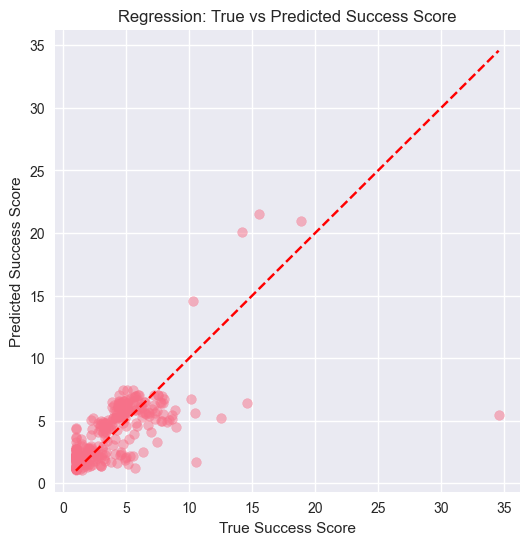

Saved bin edges for success levels: [ 1.          1.94167497  4.77509916 44.017541  ]

--- Example: Predicting success level for a new game (regression model) ---
Predicted success score: 3.45
Predicted success level: Medium


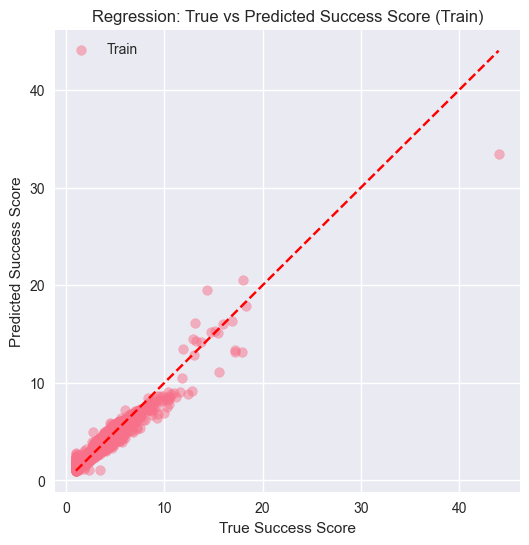

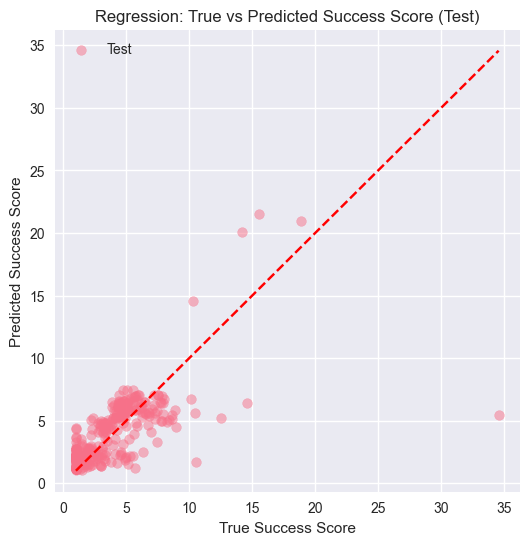

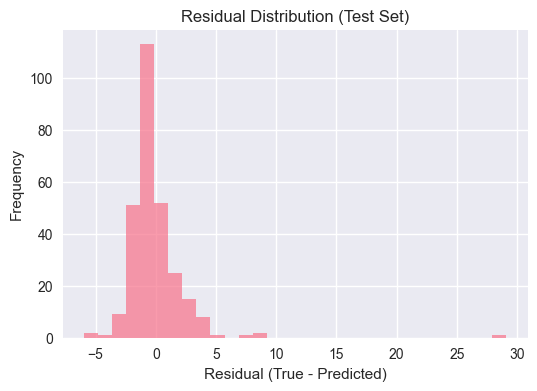

Residuals (Test set):
Mean: -0.1002
Std: 2.5249
Min: -5.9896
Max: 29.1116


In [ ]:
# 11. Regression Model: Predicting Success Score Directly
print("\n📈 REGRESSION MODEL: PREDICTING SUCCESS SCORE")
print("="*60)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Use the same combined features as before
X_train_reg = X_train_combined
X_test_reg = X_test_combined
y_train_reg = train_df_enhanced['success_score']
y_test_reg = test_df_enhanced['success_score']

# Train regression model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)

# Evaluate regression model
r2 = r2_score(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"R² (test): {r2:.4f}")
print(f"MSE (test): {mse:.4f}")
print(f"MAE (test): {mae:.4f}")

# Optional: show scatter plot of true vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("True Success Score")
plt.ylabel("Predicted Success Score")
plt.title("Regression: True vs Predicted Success Score")
plt.show()

# --- Integration: Predicting Success Level with Regression Model ---

# 1. Save bin edges and labels from the three-level qcut
labels = ['Low', 'Medium', 'High']
_, bin_edges = pd.qcut(train_df_enhanced['success_score'], q=3, labels=labels, retbins=True)
print(f"Saved bin edges for success levels: {bin_edges}")

# 2. Function to predict success_score for a new game
def predict_success_score(new_game_dict):
    """
    Predict the success_score for a new game using the regression model.
    Args:
        new_game_dict: dict with keys matching X_train_reg columns
    Returns:
        float: predicted success_score
    """
    new_game = pd.DataFrame([new_game_dict])
    for col in X_train_reg.columns:
        if col not in new_game.columns:
            new_game[col] = 0
    new_game = new_game[X_train_reg.columns].fillna(0)
    pred_score = reg.predict(new_game)[0]
    return pred_score

# 3. Function to map predicted score to success level
def map_score_to_level(score, bin_edges, labels=['Low', 'Medium', 'High']):
    """
    Map a predicted success_score to a success level using bin_edges.
    Args:
        score: float, predicted success_score
        bin_edges: array-like, bin edges from qcut
        labels: list of str, level names
    Returns:
        str: predicted level
    """
    if score <= bin_edges[1]:
        return labels[0]
    elif score <= bin_edges[2]:
        return labels[1]
    else:
        return labels[2]

# 4. Example usage
print("\n--- Example: Predicting success level for a new game (regression model) ---")
example_game = {col: 0 for col in X_train_reg.columns}  # Fill with zeros as placeholder
pred_score = predict_success_score(example_game)
pred_level = map_score_to_level(pred_score, bin_edges, labels)
print(f"Predicted success score: {pred_score:.2f}")
print(f"Predicted success level: {pred_level}")

import matplotlib.pyplot as plt

# 1. True vs Predicted scatter plot (Training set)
plt.figure(figsize=(6,6))
plt.scatter(y_train_reg, reg.predict(X_train_reg), alpha=0.5, label='Train')
plt.plot([y_train_reg.min(), y_train_reg.max()], [y_train_reg.min(), y_train_reg.max()], 'r--')
plt.xlabel("True Success Score")
plt.ylabel("Predicted Success Score")
plt.title("Regression: True vs Predicted Success Score (Train)")
plt.legend()
plt.show()

# 2. True vs Predicted scatter plot (Test set)
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, label='Test')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("True Success Score")
plt.ylabel("Predicted Success Score")
plt.title("Regression: True vs Predicted Success Score (Test)")
plt.legend()
plt.show()

# 3. Residual plot (Test set)
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, alpha=0.7)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Test Set)")
plt.show()

# 4. Print residual statistics
print("Residuals (Test set):")
print(f"Mean: {residuals.mean():.4f}")
print(f"Std: {residuals.std():.4f}")
print(f"Min: {residuals.min():.4f}")
print(f"Max: {residuals.max():.4f}")



Sample comparison (first 10 rows):
   TrueScore  PredScore TrueLevel PredLevel
0   6.184001   6.090168      High      High
1   4.467848   6.388343    Medium      High
2   2.181769   3.864849    Medium    Medium
3   2.069096   1.575549    Medium       Low
4   4.177959   5.115024    Medium      High
5   3.074309   2.751373    Medium       Low
6   3.143736   4.511879    Medium    Medium
7   5.085667   5.733384      High    Medium
8   5.813170   4.604589      High    Medium
9   2.777791   4.814136    Medium    Medium


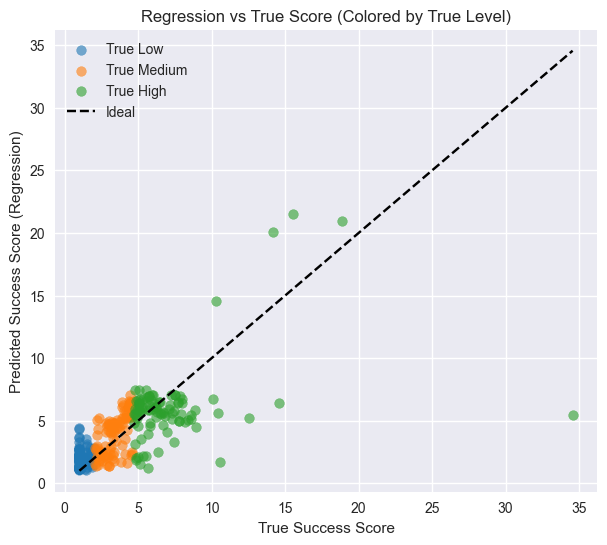

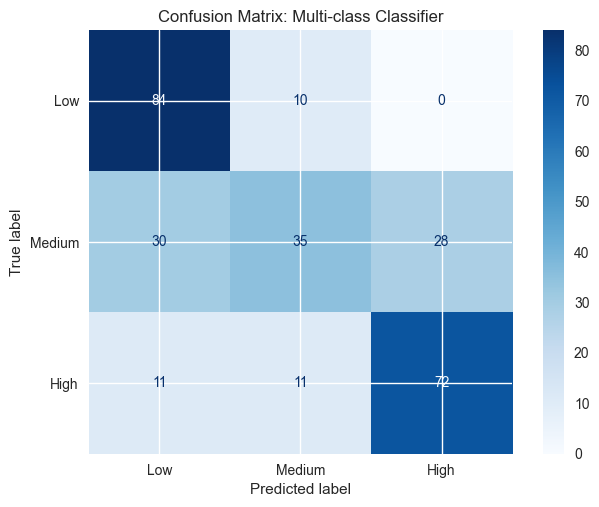


=== Statistical Comparison ===
Regression R² (test): 0.42257405553820504
Regression MAE (test): 1.454968247874952
Multi-class Accuracy (test): 0.6797153024911032

Classification report (multi-class):
              precision    recall  f1-score   support

        High       0.72      0.77      0.74        94
         Low       0.67      0.89      0.77        94
      Medium       0.62      0.38      0.47        93

    accuracy                           0.68       281
   macro avg       0.67      0.68      0.66       281
weighted avg       0.67      0.68      0.66       281



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 显示真实分数、回归预测分数、三分类预测分档
df_compare = pd.DataFrame({
    'TrueScore': y_test_reg,
    'PredScore': y_pred_reg,
    'TrueLevel': pd.qcut(y_test_reg, q=3, labels=labels),
    'PredLevel': y_pred_multi
})

print("Sample comparison (first 10 rows):")
print(df_compare.head(10))

# 2. 可视化：真实分数 vs 回归预测分数（散点图，按分类颜色区分）
plt.figure(figsize=(7,6))
colors = {'Low':'#1f77b4', 'Medium':'#ff7f0e', 'High':'#2ca02c'}
for level in labels:
    mask = df_compare['TrueLevel'] == level
    plt.scatter(df_compare.loc[mask, 'TrueScore'], df_compare.loc[mask, 'PredScore'],
                label=f"True {level}", alpha=0.6, c=colors[level])
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', label='Ideal')
plt.xlabel("True Success Score")
plt.ylabel("Predicted Success Score (Regression)")
plt.title("Regression vs True Score (Colored by True Level)")
plt.legend()
plt.show()

# 3. 分类模型混淆矩阵（真实分档 vs 分类预测分档）
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df_compare['TrueLevel'], df_compare['PredLevel'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Multi-class Classifier")
plt.show()

# 4. 统计对比
print("\n=== Statistical Comparison ===")
print("Regression R² (test):", r2_score(y_test_reg, y_pred_reg))
print("Regression MAE (test):", mean_absolute_error(y_test_reg, y_pred_reg))
print("Multi-class Accuracy (test):", accuracy_score(df_compare['TrueLevel'], df_compare['PredLevel']))
print("\nClassification report (multi-class):")
print(classification_report(df_compare['TrueLevel'], df_compare['PredLevel']))

In [ ]:
# 1. Show all required feature names for new game prediction
print("All required feature names for new game prediction:")
print(list(X_train_reg.columns))

# 2. Fill in the new game's features (replace with actual values as needed)
new_game = {
    'steam_appid': 123456,
    'steam_name': 'My New Game',
    'steam_release_date': 20240101,
    'steam_price': 59.99,
    'steam_genres': 'Action;Adventure',
    'steam_categories': 'Singleplayer;Multiplayer',
    'steam_developers': 'My Studio',
    'steam_publishers': 'My Publisher',
    'steam_supported_languages': 'English;Chinese',
    'steam_dlc_count': 0,
    'steam_has_achievements': 1,
    'steam_wishlist_count': 5000,
    'steam_metacritic': 85,
    'steam_review_count': 0,
    'steam_positive_rate': 0.0,
    'steam_positive_count': 0,
    'steam_sentiment_score': 0.0,
    'steam_game_title': 'My New Game',
    # ... add all other required features from X_train_reg.columns
    # For text embedding features, just fill the original text fields, embeddings will be handled automatically
}

# 3. Predict success score and level using regression model
score = predict_success_score(new_game)
level = map_score_to_level(score, bin_edges, labels)
print(f"Predicted success score (regression): {score:.2f}")
print(f"Predicted success level (regression): {level}")

# 4. Predict level and probabilities using multi-class classification model
result_multi = predict_success_level(new_game)
print(f"Predicted level (multi-class): {result_multi['predicted_level']}")

All required feature names for new game prediction:
['steam_appid', 'steam_dlc_count', 'steam_metacritic', 'steam_review_count', 'steam_positive_rate', 'steam_positive_count', 'steam_sentiment_score', 'steam_name_embed_0', 'steam_name_embed_1', 'steam_name_embed_2', 'steam_name_embed_3', 'steam_name_embed_4', 'steam_genres_embed_0', 'steam_genres_embed_1', 'steam_genres_embed_2', 'steam_genres_embed_3', 'steam_genres_embed_4', 'steam_categories_embed_0', 'steam_categories_embed_1', 'steam_categories_embed_2', 'steam_categories_embed_3', 'steam_categories_embed_4', 'steam_developers_embed_0', 'steam_developers_embed_1', 'steam_developers_embed_2', 'steam_developers_embed_3', 'steam_developers_embed_4', 'steam_publishers_embed_0', 'steam_publishers_embed_1', 'steam_publishers_embed_2', 'steam_publishers_embed_3', 'steam_publishers_embed_4']
Predicted success score (regression): 4.92
Predicted success level (regression): High
Predicted level (multi-class): Low
